## Modelo de Regresión Lineal


In [ ]:
import pandas as pd
df= pd.read_csv('Housing(2).csv')

#### Análisis exploratorio de datos y Feature Engineering


In [6]:
df.shape

(545, 13)

In [7]:
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
149,5600000,6600,4,2,1,yes,no,yes,no,no,0,yes,semi-furnished
62,7070000,6240,4,2,2,yes,no,no,no,yes,1,no,furnished
448,3150000,4095,2,1,1,yes,no,no,no,no,2,no,semi-furnished
289,4200000,5850,2,1,1,yes,yes,yes,no,no,2,no,semi-furnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
227,4690000,6000,2,1,1,yes,no,yes,no,yes,1,no,furnished
456,3118850,2398,3,1,1,yes,no,no,no,no,0,yes,semi-furnished
46,7525000,6000,3,2,4,yes,no,no,no,yes,1,no,furnished
445,3150000,3450,1,1,1,yes,no,no,no,no,0,no,furnished
312,4098500,3600,3,1,1,yes,no,yes,no,yes,0,yes,furnished


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
# Exploración de valores nulos en el dataset
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# Estadística
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


    Visualización de correlación y distribución de datos

In [2]:
# Importación de librerías necesarias para bool mask y heatmap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cálculo de correlación
corr= df.corr(numeric_only= True)
corr

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


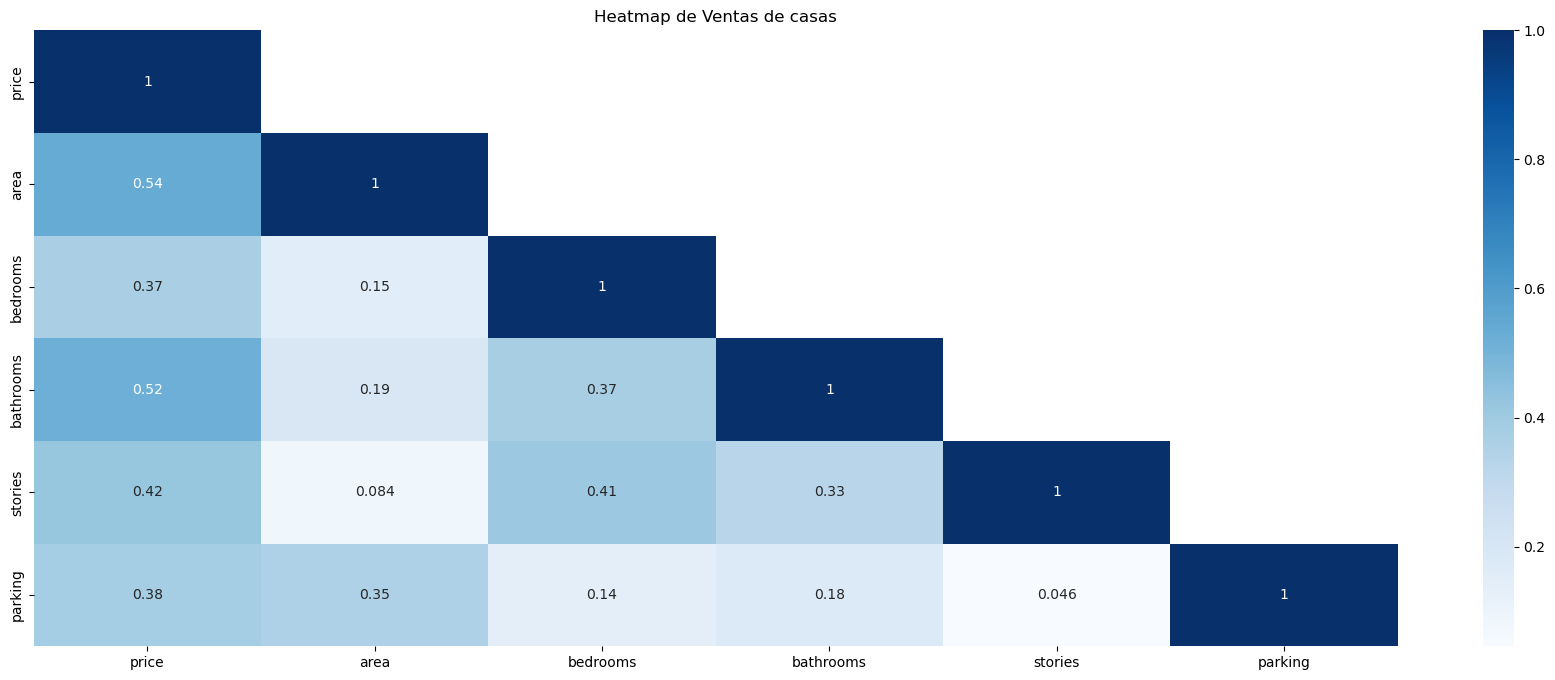

In [ ]:
plt.figure (figsize= (22, 8))
heat= corr.where(np.tril(np.ones(corr.shape).astype(bool))) # Bool mask triangular
sns.heatmap(heat, cmap= 'Blues', annot= True)               # Creación de heatmap con seaborn
plt.title('Heatmap de Ventas de casas')
plt.show()

In [21]:
# Lista de columnas numéricas
cols= ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

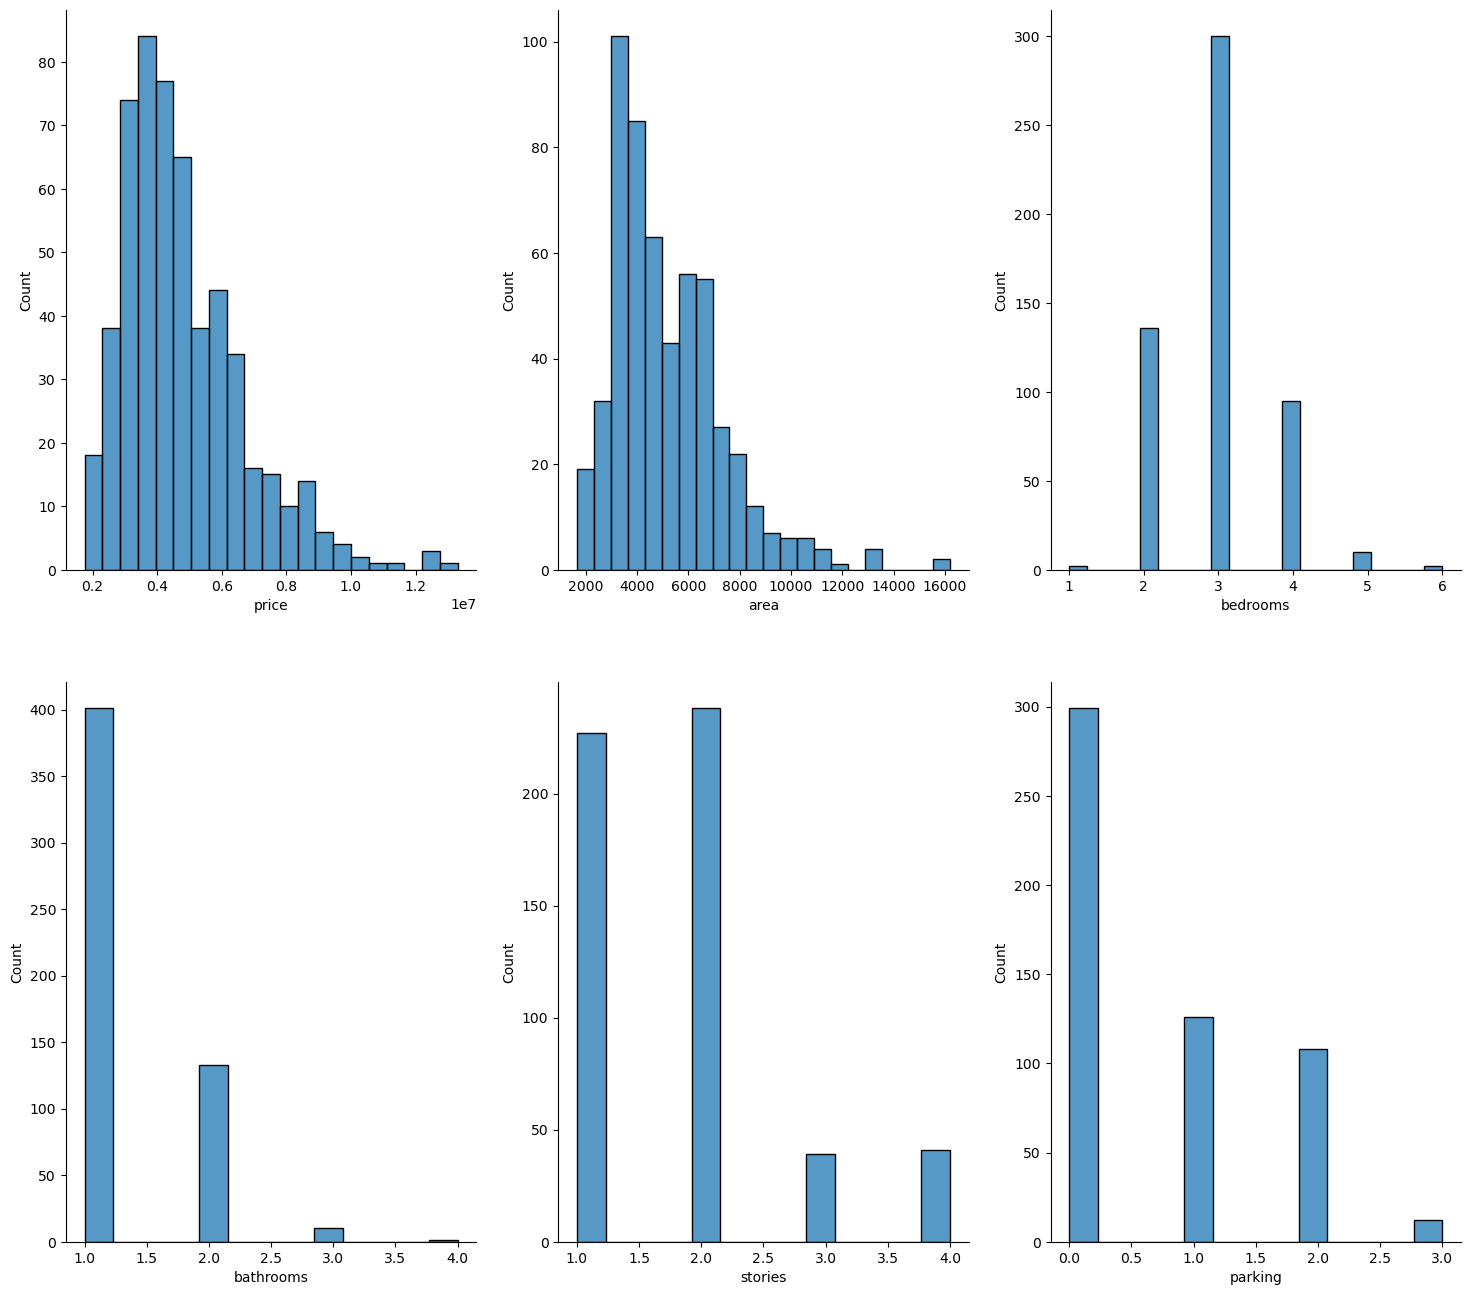

In [24]:
# Creación de histogramas 
fig, axes= plt.subplots(2, 3, figsize=(18, 16))
for i, column in enumerate(cols):
    sns.histplot(df[column], ax= axes[i//3, i%3], kde= False)
    sns.despine()

In [4]:
# Sesgos en las columnas
df.skew(numeric_only= True)

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64

<b>Observaciones: </b>
- No hay variables altamente correlacionadas en el dataset.
- Se consideró a las variables bathrooms y stories como discretas (por contener pocos valores) por lo que no pueden tener sesgos.

    Tranformación logarítmica y estandarización

In [ ]:
# Variación en las columnas bathrooms y stories
print(df['bathrooms'].value_counts())
print('\n', df['stories'].value_counts())

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64

 stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64


In [79]:
# Copia del dataframe para realizar cambios
df2= df

In [80]:
# Tranformación logarítmica de la variable area
df2['area_log']= np.log(df2['area']+1)

In [5]:
# Importación de StandardScaler para estandarizar la variable
from sklearn.preprocessing import StandardScaler

In [81]:
# Estandarización de variable
scaler= StandardScaler()
df2[['area_log']]= scaler.fit_transform(df2[['area_log']])

In [67]:
df2['area_log'].skew()

np.float64(0.13374740415415834)

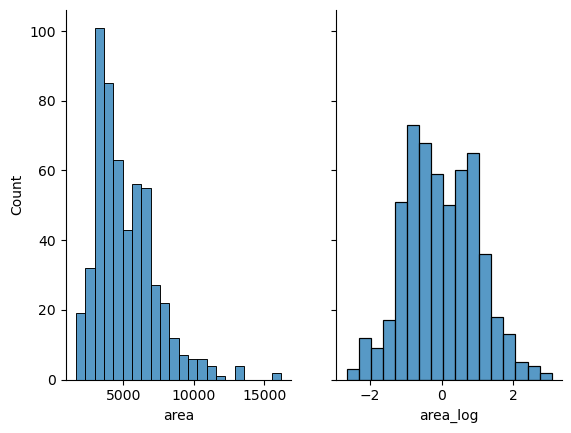

In [8]:
# Comparación de la variable area antes y después de la estandarización
fig, (ax0, ax1)= plt.subplots( 1, 2, sharey= True)
sns.histplot(df2['area'], ax= ax0, kde= False)
sns.histplot(df2['area_log'], ax= ax1, kde= False)
sns.despine()

    Transformación de variables binarias

In [11]:
# Variación de datos en las columnas
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
area_log            284
dtype: int64

In [ ]:
# Registros en variables no numéricas
print(df['mainroad'].value_counts())
print('\n', df['guestroom'].value_counts())
print('\n', df['basement'].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64

 guestroom
no     448
yes     97
Name: count, dtype: int64

 basement
no     354
yes    191
Name: count, dtype: int64


In [33]:
print('\n', df['hotwaterheating'].value_counts())
print('\n', df['airconditioning'].value_counts())
print('\n', df['prefarea'].value_counts())
print('\n', df['furnishingstatus'].value_counts())


 hotwaterheating
no     520
yes     25
Name: count, dtype: int64

 airconditioning
no     373
yes    172
Name: count, dtype: int64

 prefarea
no     417
yes    128
Name: count, dtype: int64

 furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [ ]:
# Filtro con la proporción de registros en la columna furnishingstatus (3 registros)
furnishingstatus_counts= df['furnishingstatus'].value_counts(normalize= True)

In [36]:
furnishingstatus_counts

furnishingstatus
semi-furnished    0.416514
unfurnished       0.326606
furnished         0.256881
Name: proportion, dtype: float64

In [ ]:
# Categorías que cumplen el 5% del umbral de registros
# Los registros están balanceados
furnishingstatus_counts < 0.05

furnishingstatus
semi-furnished    False
unfurnished       False
furnished         False
Name: proportion, dtype: bool

In [82]:
# Transformación de columnas binarias (yes/no)
df2['mainroad']= df2['mainroad'].map({'yes': 1, 'no': 0})

In [83]:
df2.sample(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_log
244,4550000,5320,3,1,2,1,yes,yes,no,no,0,yes,semi-furnished,0.28
466,3010000,3090,3,1,2,0,no,no,no,no,0,no,semi-furnished,-1.08
293,4200000,4410,2,1,1,0,no,no,no,no,1,no,unfurnished,-0.19


In [84]:
df2['guestroom']= df2['guestroom'].map({'yes': 1, 'no': 0})
df2['basement']= df2['basement'].map({'yes': 1, 'no': 0})
df2['hotwaterheating']= df2['hotwaterheating'].map({'yes': 1, 'no': 0})
df2['airconditioning']= df2['airconditioning'].map({'yes': 1, 'no': 0})
df2['prefarea']= df2['prefarea'].map({'yes': 1, 'no': 0})

In [85]:
df2.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_log
249,4543000,4990,4,2,2,1,1,1,0,0,0,1,furnished,0.12
479,2940000,3660,4,1,2,0,0,0,0,0,0,0,unfurnished,-0.66
497,2660000,3934,2,1,1,1,0,0,0,0,0,0,unfurnished,-0.48
253,4515000,3520,2,1,2,1,0,0,0,0,0,1,furnished,-0.75
64,7000000,11175,3,1,1,1,0,1,0,1,1,1,furnished,2.15


In [86]:
# Transformación a variable categórica
df2['furnishingstatus']= df2['furnishingstatus'].astype('category')

<b>Observaciones: </b>
- La mayor parte de las columnas no numéricas son binarias (yes/no).
- La columna furnishingstatus tiene balance del 5 %, por lo que no se realiza balanceo y agrupación de variables. Se transforma en categórica.

#### Split del modelo

In [ ]:
# Importación de librerías para realizar el split y la definición del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
# Separación de variables independientes
X= df2.drop(['price'], axis= 1)
# Separación de clase o variable dependiente
y= df2[['price']]

X= pd.get_dummies(X, columns= ['furnishingstatus'], drop_first= True, dtype= int)  # Conversión de la variable categórica a dummies

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.30, random_state= 1)  # Variables de entrenamiento y prueba

In [88]:
X.head(5)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,area_log,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,1.12,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,1.59,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1.86,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,1.15,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,1.12,0,0


In [89]:
y.head(5)

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


In [90]:
# Longitud de los datasets
print('{0:0.2f}% de datos reservados para entrenar'.format((len(X_train)/len(df2.index)) * 100))
print('{0:0.2f}% de datos reservados para evaluar'.format((len(X_test)/len(df2.index)) * 100))

69.91% de datos reservados para entrenar
30.09% de datos reservados para evaluar


#### Entrenamiento de regresión lineal a la variable Price

In [91]:
# Ejecución de la regresión lineal con la función fit
model= LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [92]:
# Coeficiente de regresión R2 de entrenamiento
model.score(X_train, y_train)

0.6851387832646237

In [93]:
# Coeficiente de regresión R2 de prueba
model.score(X_test, y_test)

0.6688873117067371

In [94]:
# Intercepto
print('Intercepto:', model.intercept_)

Intercepto: [1096350.5162469]


In [95]:
# Creación de diccionario coef para almacenar los coeficientes de X_train
coef= {}
for idx, column in enumerate(X_train.columns):
    coef[column]= model.coef_[0][idx]

In [96]:
# Conversión del diccionario a Dataframe
coef_df= pd.DataFrame.from_dict(coef, orient= 'index', columns= ['Coeficiente: '])

In [ ]:
# Mostrar números sin notación científica
pd.set_option('display.float_format', '{:.2f}'.format)

In [97]:
# Coeficientes de las columnas
coef_df

,Coeficiente:
area,63.24
bedrooms,50499.30
bathrooms,1011729.59
stories,520472.47
mainroad,400574.00
guestroom,211062.55
basement,569134.92
hotwaterheating,819478.09
airconditioning,579800.13
parking,264851.95


    Predicción

In [98]:
# Variable que almacena la predicción de la prueba
y_predict= model.predict(X_test)

In [99]:
# Comparación de lo actual vs la predicción (redondeada a enteros)
preds_df= pd.DataFrame({'Actual': y_test.squeeze(), 'Predicción': y_predict.squeeze().round(0)})
preds_df

,Actual,Predicción
62,7070000,6303141.00
247,4550000,6339158.00
142,5600000,6490798.00
107,6125000,5641490.00
483,2940000,4407810.00
...,...,...
450,3150000,4058001.00
542,1750000,2650416.00
408,3430000,2784662.00
80,6629000,5866277.00


    Evaluación

In [48]:
# Importación de librerías para el uso de métricas como MAE, MSE y RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [100]:
# Promedio de la suma absoluta de las diferencias
mae= mean_absolute_error(y_test, y_predict)
# Promedio de la suma absoluta de las diferencias al cuadrado
mse= mean_squared_error(y_test, y_predict)
# Raíz cuadrada de MSE
rmse= np.sqrt(mse)

In [101]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squarred error: {mse:.2f}')
print(f'Root mean squarred error: {rmse:.2f}')

Mean absolute error: 853221.99
Mean squarred error: 1347773056772.43
Root mean squarred error: 1160936.28


In [ ]:
# Porcentaje de error: Se divide el RMSE contra el precio promedio
(rmse/y.mean()) *100

price   24.35
dtype: float64

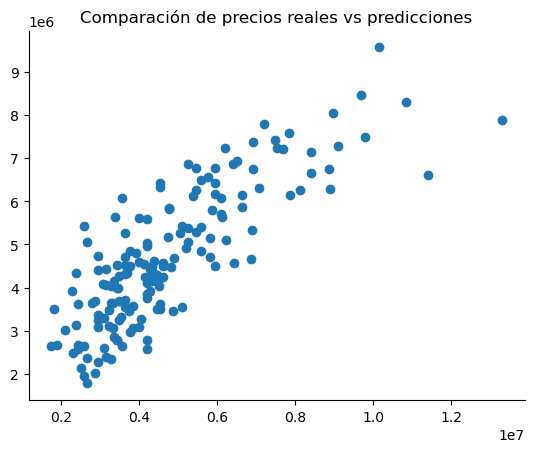

In [ ]:
# Gráfico de regresión lineal de residuos entre precios reales y precios predichos
plt.scatter(y_test, y_predict)
plt.title('Comparación de precios reales vs predicciones')
sns.despine()

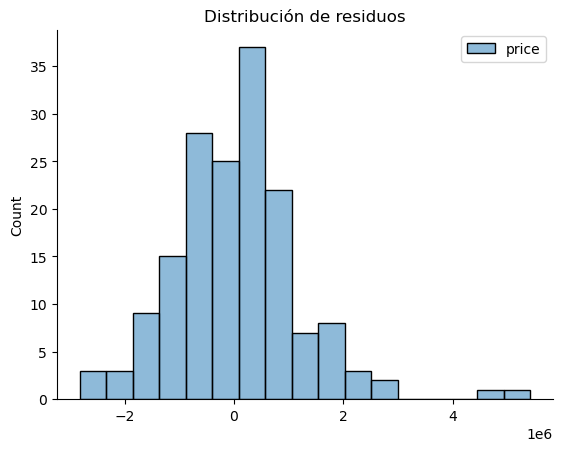

In [ ]:
# Histograma de errores o residuos, forma de distribución normal
sns.histplot(y_test - y_predict)
plt.title('Distribución de residuos')
sns.despine()

In [105]:
# Orden de importancia de variables por coeficiente
coef_df.sort_values(by= 'Coeficiente: ', ascending= False)

,Coeficiente:
bathrooms,1011729.59
hotwaterheating,819478.09
airconditioning,579800.13
basement,569134.92
prefarea,520783.10
stories,520472.47
area_log,439374.27
mainroad,400574.00
parking,264851.95
guestroom,211062.55


In [ ]:
# Valor absoluto de los coeficientes (Ya que hay valores negativos en el dataframe)
coef_abs= coef_df.abs()

In [122]:
# Cálculo del porcentaje de aportación de cada variable
((coef_abs/coef_abs.sum())* 100).sort_values(by= 'Coeficiente: ', ascending= False)

,Coeficiente:
bathrooms,17.23
hotwaterheating,13.95
airconditioning,9.87
basement,9.69
prefarea,8.87
stories,8.86
area_log,7.48
furnishingstatus_unfurnished,6.95
mainroad,6.82
parking,4.51


In [108]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,area_log,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,1.12,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,1.59,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1.86,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,1.15,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,1.12,0,0


In [ ]:
# Variables no binarias
cols= ['bedrooms', 'bathrooms', 'stories', 'parking', 'area_log']

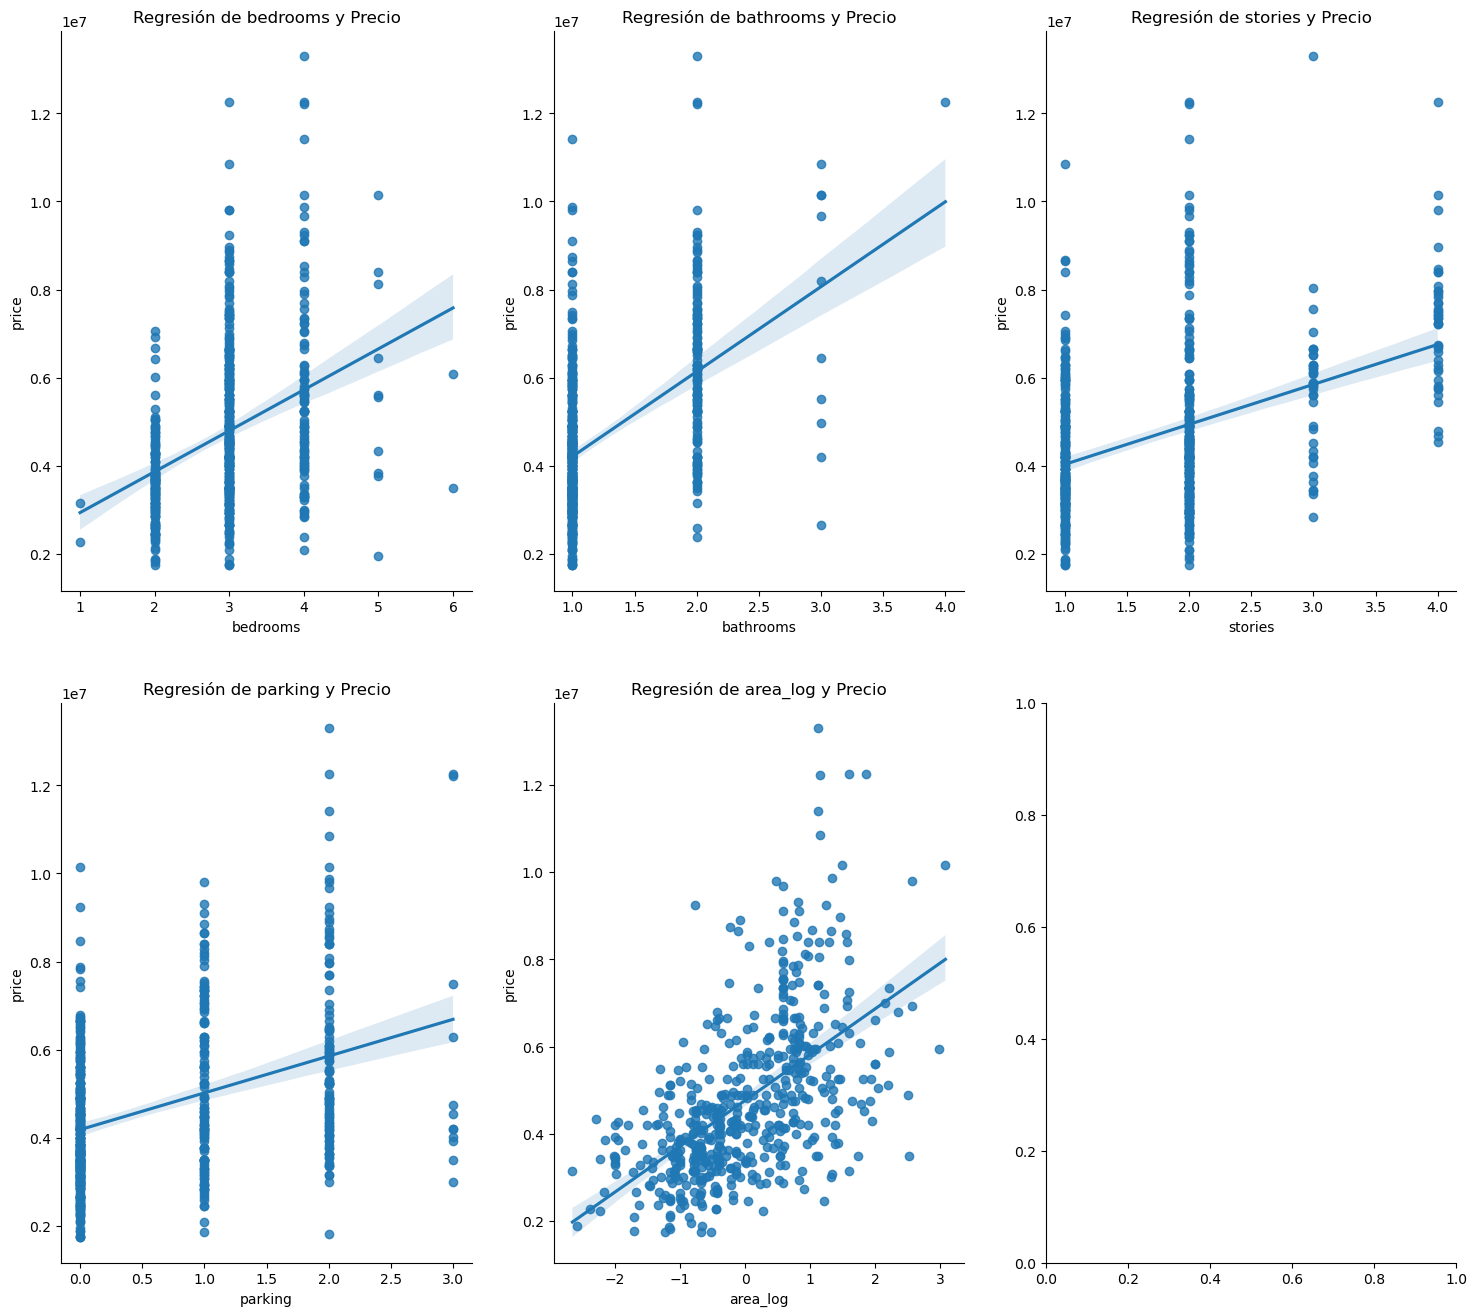

In [ ]:
# Gráficos de dispersión de las columnas no binarias
fig, axes= plt.subplots(2, 3, figsize=(18, 16))
for i, column in enumerate(cols):
    sns.regplot(x= df2[column], y= y, ax= axes[i//3, i%3]).set(title= f'Regresión de {column} y Precio')
    sns.despine()

<b>Observaciones: </b>
- El modelo explica el 66% la variabilidad de los precios. 
- El modelo se equivoca alrededor de 853 mil dólares (MAE).
- El modelo se desvía en promedio 1.16 millones o el 24% respecto al precio real (RMSE).
- La variable con el coeficiente de más peso en el modelo es bathrooms con 17% respecto a las demás variables.